In [1]:
# Cell 1: Import libraries and load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix

data = load_breast_cancer(as_frame=True)
df = data.frame

print(df.shape)
print("\nTarget distribution:\n", df['target'].value_counts())
print("\nTarget meaning:", dict(zip([0,1], data.target_names)))

(569, 31)

Target distribution:
 target
1    357
0    212
Name: count, dtype: int64

Target meaning: {0: np.str_('malignant'), 1: np.str_('benign')}


In [2]:
# Cell 2: Split and scale features
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape, "| Test shape:", X_test_scaled.shape)

Train shape: (455, 30) | Test shape: (114, 30)


In [3]:
# Cell 3: Train SVM - Linear kernel
svm_linear = SVC(kernel='linear', probability=True, random_state=42)
svm_linear.fit(X_train_scaled, y_train)

y_pred_linear = svm_linear.predict(X_test_scaled)
y_proba_linear = svm_linear.predict_proba(X_test_scaled)[:, 1]

print("Linear Kernel Results:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_linear):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_linear):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_linear):.4f}")
print(f"AUC:       {roc_auc_score(y_test, y_proba_linear):.4f}")

Linear Kernel Results:
Accuracy:  0.9737
Precision: 0.9859
Recall:    0.9722
AUC:       0.9964


In [4]:
# Cell 4: Train SVM - RBF kernel
svm_rbf = SVC(kernel='rbf', probability=True, random_state=42)
svm_rbf.fit(X_train_scaled, y_train)

y_pred_rbf = svm_rbf.predict(X_test_scaled)
y_proba_rbf = svm_rbf.predict_proba(X_test_scaled)[:, 1]

print("RBF Kernel Results:")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rbf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rbf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rbf):.4f}")
print(f"AUC:       {roc_auc_score(y_test, y_proba_rbf):.4f}")

RBF Kernel Results:
Accuracy:  0.9825
Precision: 0.9861
Recall:    0.9861
AUC:       0.9950


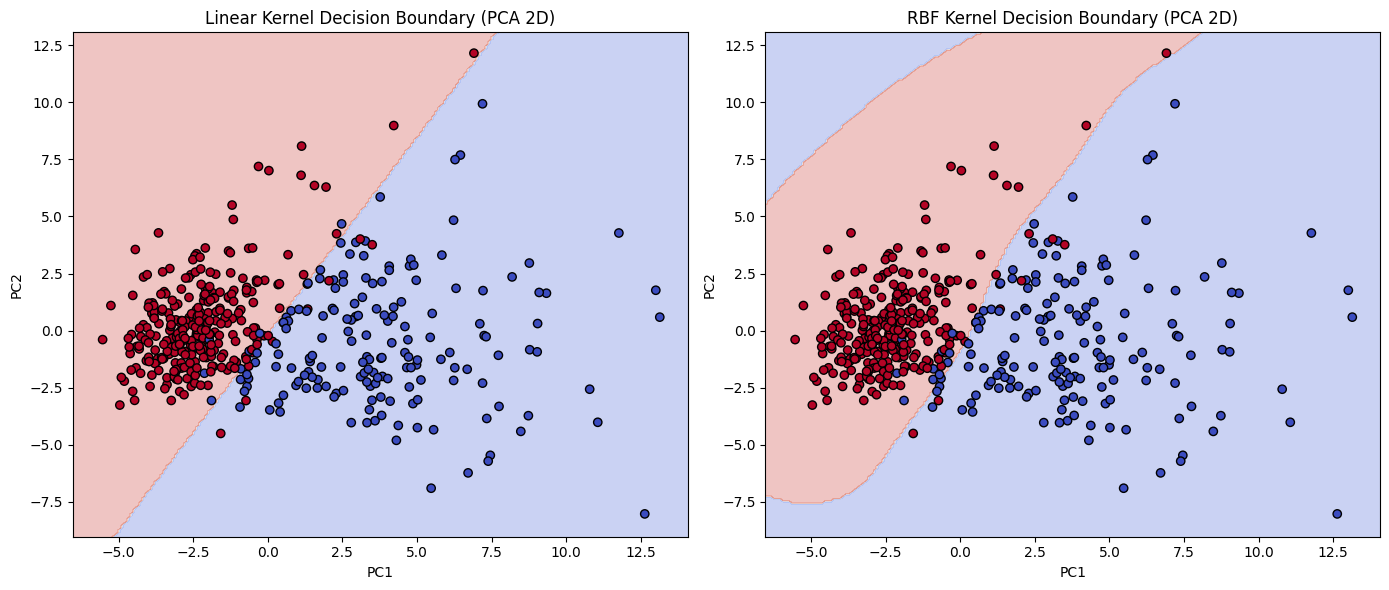

In [5]:
# Cell 5: Visualize decision boundary (2D via PCA)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

# Retrain both kernels on the 2D PCA-reduced data, just for visualization
svm_linear_2d = SVC(kernel='linear').fit(X_train_pca, y_train)
svm_rbf_2d = SVC(kernel='rbf').fit(X_train_pca, y_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, model, title in zip(axes, [svm_linear_2d, svm_rbf_2d], ['Linear Kernel', 'RBF Kernel']):
    x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
    y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='coolwarm', edgecolors='k')
    ax.set_title(f'{title} Decision Boundary (PCA 2D)')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.tight_layout()
plt.show()

In [6]:
# Cell 6: Summary
print("="*50)
print("TASK 6 SUMMARY: SVM for Classification")
print("="*50)
print(f"Dataset: Breast Cancer Wisconsin ({df.shape[0]} samples, 30 features)")
print(f"\nLinear Kernel -> Accuracy: 0.9737 | Precision: 0.9859 | Recall: 0.9722 | AUC: 0.9964")
print(f"RBF Kernel    -> Accuracy: 0.9825 | Precision: 0.9861 | Recall: 0.9861 | AUC: 0.9950")
print(f"\nKey insight: RBF kernel achieved higher recall (98.6% vs 97.2%),")
print(f"meaning it missed fewer actual malignant cases - clinically the")
print(f"more important metric here, since a false negative (missed")
print(f"cancer) is far costlier than a false positive. Linear kernel had")
print(f"a marginally higher AUC. Both kernels performed excellently,")
print(f"showing the data is close to linearly separable, with RBF's")
print(f"added flexibility providing a small but meaningful edge in recall.")

TASK 6 SUMMARY: SVM for Classification
Dataset: Breast Cancer Wisconsin (569 samples, 30 features)

Linear Kernel -> Accuracy: 0.9737 | Precision: 0.9859 | Recall: 0.9722 | AUC: 0.9964
RBF Kernel    -> Accuracy: 0.9825 | Precision: 0.9861 | Recall: 0.9861 | AUC: 0.9950

Key insight: RBF kernel achieved higher recall (98.6% vs 97.2%),
meaning it missed fewer actual malignant cases - clinically the
more important metric here, since a false negative (missed
cancer) is far costlier than a false positive. Linear kernel had
a marginally higher AUC. Both kernels performed excellently,
showing the data is close to linearly separable, with RBF's
added flexibility providing a small but meaningful edge in recall.
